# Ce notebook permet de préparer la table et les variables pour réaliser le score de churn du TP

# Sommaire

1. [Import](#sect1)
2. [Nettoyage des données](#sect2)
3. [Export des données pour le notebook "ModelesPridictifChurn"](#sect3)
4. [Analyse descriptive sur les données normalisées](#sect4)

In [78]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
repertoire = "../data/"
os.chdir(repertoire)

# 1. Import <a name="sect1" ></a> 

### Data -> données de score d'attrition dans le secteur des Telco

In [79]:
churn_df = pd.read_csv('churn.csv')

In [80]:
churn_df.shape

(3333, 21)

In [81]:
churn_df.head()

,State,Account Length,Area Code,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


In [82]:
churn_df.columns

Index(['State', 'Account Length', 'Area Code', 'Phone', 'Int'l Plan',
       'VMail Plan', 'VMail Message', 'Day Mins', 'Day Calls', 'Day Charge',
       'Eve Mins', 'Eve Calls', 'Eve Charge', 'Night Mins', 'Night Calls',
       'Night Charge', 'Intl Mins', 'Intl Calls', 'Intl Charge',
       'CustServ Calls', 'Churn?'],
      dtype='object')

In [83]:
churn_df.dtypes

State              object
Account Length      int64
Area Code           int64
Phone              object
Int'l Plan         object
VMail Plan         object
VMail Message       int64
Day Mins          float64
Day Calls           int64
Day Charge        float64
Eve Mins          float64
Eve Calls           int64
Eve Charge        float64
Night Mins        float64
Night Calls         int64
Night Charge      float64
Intl Mins         float64
Intl Calls          int64
Intl Charge       float64
CustServ Calls      int64
Churn?             object
dtype: object

# 2. Nettoyage des données <a name="sect2" ></a> 

In [84]:
# Types des colonnes pour transformation
feat_quali = ['Area Code']
feat_quanti = [ 'Account Length', 'VMail Message', 'Day Mins', 'Day Calls', 'Day Charge',
       'Eve Mins', 'Eve Calls', 'Eve Charge', 'Night Mins', 'Night Calls',
       'Night Charge', 'Intl Mins', 'Intl Calls', 'Intl Charge',
       'CustServ Calls']
feat_bool = ["Int'l Plan",'VMail Plan']
target = "Churn?"

In [85]:
# Area Code -> Catégorielle
churn_df['Area Code'] = churn_df['Area Code'].astype(str)


In [86]:
# Transformation de la variable Target en numérique
churn_df.loc[churn_df['Churn?'] == "True.",'Churn?'] = 1
churn_df.loc[churn_df['Churn?'] == "False.",'Churn?'] = 0

y = churn_df['Churn?'].astype(int)
# 14,5% de Churners
print(y.mean())

0.14491449144914492


In [87]:
# Transformation des booléens en Numpy Bool
for col in feat_bool:
        churn_df[col] = churn_df[col] == "yes"


In [88]:
type(churn_df["Int'l Plan"].iloc[0])

numpy.bool

In [89]:
pip install dython

Note: you may need to restart the kernel to use updated packages.


### Analyse de corrélation sur données mixtes

Notre dataset contient des variables de types différents : **numériques** et **catégorielles**. Cela rend l’analyse des corrélations non triviale, car les méthodes classiques comme le coefficient de Pearson ne s’appliquent qu’aux variables numériques.

Pour contourner cette limite, nous utilisons la fonction `associations()` du package `dython`, qui applique automatiquement la mesure adaptée selon les types de variables :

- **Numérique ↔ Numérique** : coefficient de Pearson  
- **Catégorielle ↔ Catégorielle** : V de Cramér ou U de Theil  
- **Numérique ↔ Catégorielle** : ratio de corrélation (η²)

Cela permet d’obtenir une matrice de corrélation complète, adaptée aux jeux de données hétérogènes.


In [90]:
from dython.nominal import associations

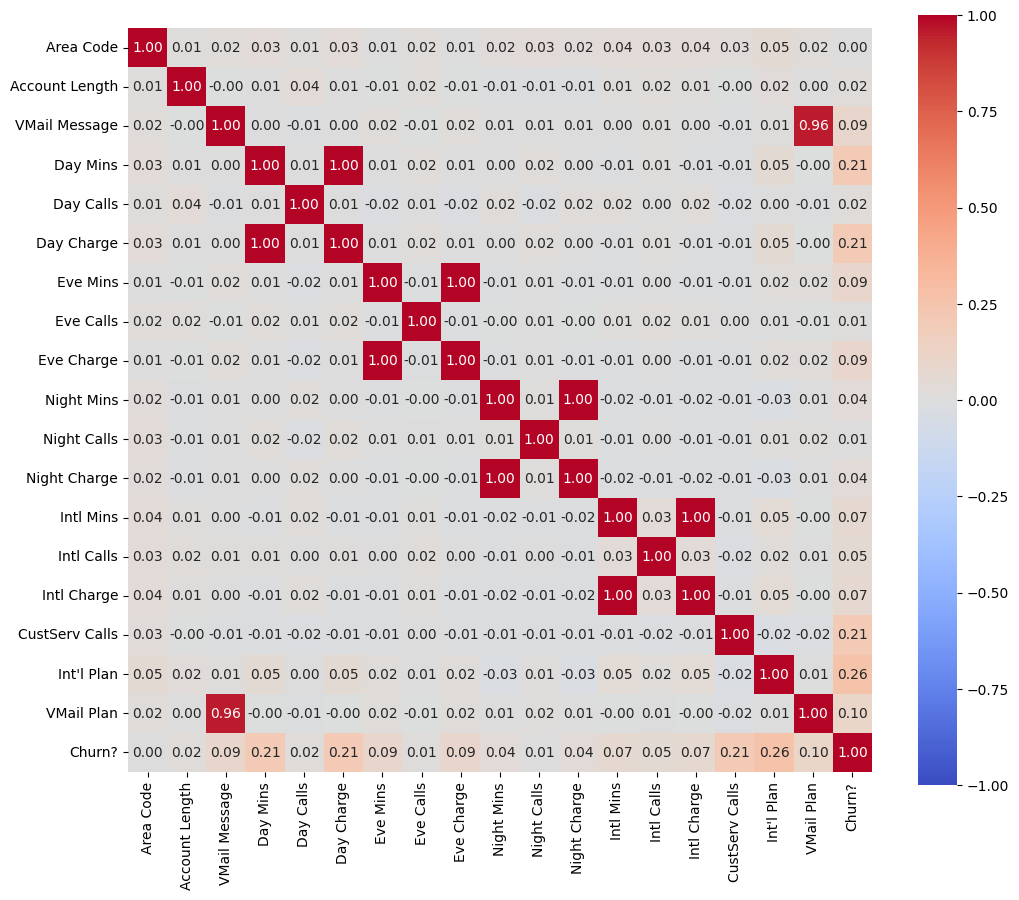

In [91]:
fig, ax = plt.subplots(figsize=(12, 10))
assoc = associations(churn_df[feat_quali + feat_quanti + feat_bool + [target]],
                     nominal_columns='auto',
                     numerical_columns='auto',
                     figsize=(12,10),
                     annot=True,
                     cmap='coolwarm',
                     ax=ax)


In [92]:
stats = churn_df.describe(include='all')
stats.T
churn_df[feat_quanti + [target] ].corr()

,Account Length,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?
Account Length,1.000000,-0.004628,0.006216,0.038470,0.006214,-0.006757,0.019260,-0.006745,-0.008955,-0.013176,-0.008960,0.009514,0.020661,0.009546,-0.003796,0.016541
VMail Message,-0.004628,1.000000,0.000778,-0.009548,0.000776,0.017562,-0.005864,0.017578,0.007681,0.007123,0.007663,0.002856,0.013957,0.002884,-0.013263,-0.089728
Day Mins,0.006216,0.000778,1.000000,0.006750,1.000000,0.007043,0.015769,0.007029,0.004323,0.022972,0.004300,-0.010155,0.008033,-0.010092,-0.013423,0.205151
Day Calls,0.038470,-0.009548,0.006750,1.000000,0.006753,-0.021451,0.006462,-0.021449,0.022938,-0.019557,0.022927,0.021565,0.004574,0.021666,-0.018942,0.018459
Day Charge,0.006214,0.000776,1.000000,0.006753,1.000000,0.007050,0.015769,0.007036,0.004324,0.022972,0.004301,-0.010157,0.008032,-0.010094,-0.013427,0.205151
Eve Mins,-0.006757,0.017562,0.007043,-0.021451,0.007050,1.000000,-0.011430,1.000000,-0.012584,0.007586,-0.012593,-0.011035,0.002541,-0.011067,-0.012985,0.092796
Eve Calls,0.019260,-0.005864,0.015769,0.006462,0.015769,-0.011430,1.000000,-0.011423,-0.002093,0.007710,-0.002056,0.008703,0.017434,0.008674,0.002423,0.009233
Eve Charge,-0.006745,0.017578,0.007029,-0.021449,0.007036,1.000000,-0.011423,1.000000,-0.012592,0.007596,-0.012601,-0.011043,0.002541,-0.011074,-0.012987,0.092786
Night Mins,-0.008955,0.007681,0.004323,0.022938,0.004324,-0.012584,-0.002093,-0.012592,1.000000,0.011204,0.999999,-0.015207,-0.012353,-0.015180,-0.009288,0.035493
Night Calls,-0.013176,0.007123,0.022972,-0.019557,0.022972,0.007586,0.007710,0.007596,0.011204,1.000000,0.011188,-0.013605,0.000305,-0.013630,-0.012802,0.006141


##### Analyse de quelques variables catégorielles 

In [93]:
# Analyse des liens entre la variable catégorielle "Area Code" afin de recoder : 
# semble ne pas avoir de lien mais conservation de la colonne pour des liens non binaires
print(pd.crosstab(churn_df['Area Code'],y, normalize='index'))


Churn?            0         1
Area Code                    
408        0.854415  0.145585
415        0.857402  0.142598
510        0.851190  0.148810


In [94]:
# par contre les deux var qui indiquent si le client paie pour un service international ou VM sont très discriminantes
print(pd.crosstab(churn_df["Int'l Plan"],y, normalize='index'))
print(pd.crosstab(churn_df["VMail Plan"],y, normalize='index'))

Churn?             0         1
Int'l Plan                    
False       0.885050  0.114950
True        0.575851  0.424149
Churn?             0         1
VMail Plan                    
False       0.832849  0.167151
True        0.913232  0.086768


In [95]:
churn_df['State'].value_counts()

State
WV    106
MN     84
NY     83
AL     80
OH     78
WI     78
OR     78
WY     77
VA     77
CT     74
ID     73
MI     73
VT     73
TX     72
UT     72
IN     71
MD     70
KS     70
NJ     68
NC     68
MT     68
WA     66
CO     66
NV     66
MS     65
MA     65
RI     65
AZ     64
MO     63
FL     63
NM     62
ME     62
ND     62
OK     61
NE     61
DE     61
SD     60
SC     60
KY     59
IL     58
NH     56
AR     55
DC     54
GA     54
HI     53
TN     53
AK     52
LA     51
PA     45
IA     44
CA     34
Name: count, dtype: int64

In [96]:
# étude du state
print(pd.crosstab(churn_df['State'],y,normalize='index'))

Churn?         0         1
State                     
AK      0.942308  0.057692
AL      0.900000  0.100000
AR      0.800000  0.200000
AZ      0.937500  0.062500
CA      0.735294  0.264706
CO      0.863636  0.136364
CT      0.837838  0.162162
DC      0.907407  0.092593
DE      0.852459  0.147541
FL      0.873016  0.126984
GA      0.851852  0.148148
HI      0.943396  0.056604
IA      0.931818  0.068182
ID      0.876712  0.123288
IL      0.913793  0.086207
IN      0.873239  0.126761
KS      0.814286  0.185714
KY      0.864407  0.135593
LA      0.921569  0.078431
MA      0.830769  0.169231
MD      0.757143  0.242857
ME      0.790323  0.209677
MI      0.780822  0.219178
MN      0.821429  0.178571
MO      0.888889  0.111111
MS      0.784615  0.215385
MT      0.794118  0.205882
NC      0.838235  0.161765
ND      0.903226  0.096774
NE      0.918033  0.081967
NH      0.839286  0.160714
NJ      0.735294  0.264706
NM      0.903226  0.096774
NV      0.787879  0.212121
NY      0.819277  0.180723
O

In [97]:
len(churn_df['State'].unique())
# 51 valeurs
# soit on garde et on crée des dummy
# soit on créé des regroupements "métiers" (non abordé dans la formation)

51

Dichotomisation des variables qualitative 

In [98]:
# les dummies
churn_df = pd.get_dummies(churn_df,columns=feat_quali, drop_first=True)

In [99]:
churn_df.head()

,State,Account Length,Phone,Int'l Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,...,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls,Churn?,Area Code_415,Area Code_510
0,KS,128,382-4657,False,True,25,265.1,110,45.07,197.4,...,244.7,91,11.01,10.0,3,2.70,1,0,True,False
1,OH,107,371-7191,False,True,26,161.6,123,27.47,195.5,...,254.4,103,11.45,13.7,3,3.70,1,0,True,False
2,NJ,137,358-1921,False,False,0,243.4,114,41.38,121.2,...,162.6,104,7.32,12.2,5,3.29,0,0,True,False
3,OH,84,375-9999,True,False,0,299.4,71,50.90,61.9,...,196.9,89,8.86,6.6,7,1.78,2,0,False,False
4,OK,75,330-6626,True,False,0,166.7,113,28.34,148.3,...,186.9,121,8.41,10.1,3,2.73,3,0,True,False


In [100]:
#############################################################################################
# Traitement du state en  remplacant l'état par la moyenne de y dans chaque état
# Faire ce travail c'est déjà faire un modèle simple donc il faut absolument refaire l'échantillon d'apprentissage
#############################################################################################
# split Apprentissage Test
from sklearn.model_selection import train_test_split 
state_train, state_test, y_train, y_test = train_test_split(churn_df['State'],y,  test_size=0.3,random_state=42)


In [101]:
taux_reponse_state_train=pd.crosstab(state_train,y_train).apply(lambda r: r/r.sum(), axis=1)[1]
taux_reponse_state_test=pd.crosstab(state_test,y_test).apply(lambda r: r/r.sum(), axis=1)[1]



### Taux de churn moyen par état : Analyser l'erreur entre l'approximation sur un sous ensemble des données vs toutes les données 

In [102]:
df_churn_ratio_by_state_ = pd.crosstab(churn_df['State'],y,normalize='index')

for state in pd.crosstab(churn_df['State'],y,normalize='index').index:
    print(state, df_churn_ratio_by_state_.loc[state].values[1],taux_reponse_state_test.loc[state] )

AK 0.057692307692307696 0.0
AL 0.1 0.15384615384615385
AR 0.2 0.0
AZ 0.0625 0.05
CA 0.2647058823529412 0.4444444444444444
CO 0.13636363636363635 0.2222222222222222
CT 0.16216216216216217 0.2
DC 0.09259259259259259 0.125
DE 0.14754098360655737 0.2631578947368421
FL 0.12698412698412698 0.11764705882352941
GA 0.14814814814814814 0.0
HI 0.05660377358490566 0.0
IA 0.06818181818181818 0.125
ID 0.1232876712328767 0.17391304347826086
IL 0.08620689655172414 0.05555555555555555
IN 0.1267605633802817 0.0
KS 0.18571428571428572 0.17391304347826086
KY 0.13559322033898305 0.06666666666666667
LA 0.0784313725490196 0.08333333333333333
MA 0.16923076923076924 0.2777777777777778
MD 0.24285714285714285 0.21052631578947367
ME 0.20967741935483872 0.21739130434782608
MI 0.2191780821917808 0.2222222222222222
MN 0.17857142857142858 0.13636363636363635
MO 0.1111111111111111 0.2
MS 0.2153846153846154 0.2608695652173913
MT 0.20588235294117646 0.18181818181818182
NC 0.16176470588235295 0.125
ND 0.0967741935483871 

In [103]:
print(taux_reponse_state_test) 

State
AK    0.000000
AL    0.153846
AR    0.000000
AZ    0.050000
CA    0.444444
CO    0.222222
CT    0.200000
DC    0.125000
DE    0.263158
FL    0.117647
GA    0.000000
HI    0.000000
IA    0.125000
ID    0.173913
IL    0.055556
IN    0.000000
KS    0.173913
KY    0.066667
LA    0.083333
MA    0.277778
MD    0.210526
ME    0.217391
MI    0.222222
MN    0.136364
MO    0.200000
MS    0.260870
MT    0.181818
NC    0.125000
ND    0.190476
NE    0.034483
NH    0.166667
NJ    0.263158
NM    0.062500
NV    0.142857
NY    0.178571
OH    0.100000
OK    0.157895
OR    0.034483
PA    0.083333
RI    0.111111
SC    0.238095
SD    0.230769
TN    0.000000
TX    0.294118
UT    0.192308
VA    0.000000
VT    0.200000
WA    0.333333
WI    0.111111
WV    0.081081
WY    0.095238
Name: 1, dtype: float64


In [104]:
del state_test,y_test,  taux_reponse_state_test
del state_train
# on remplace le state par le taux de reponse associé
list(taux_reponse_state_train)
# replace une liste par une liste
churn_df['State'].replace(list(taux_reponse_state_train.index), list(taux_reponse_state_train), inplace=True)
churn_df.rename(columns={"State": "churnMoy_state"},inplace=True)

/tmp/ipykernel_1915/692777394.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  churn_df['State'].replace(list(taux_reponse_state_train.index), list(taux_reponse_state_train), inplace=True)
/tmp/ipykernel_1915/692777394.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  churn_df['State'].replace(

Suppression de variables inutiles

In [105]:
to_drop=['Phone']
churn_df = churn_df.drop(to_drop,axis=1)
churn_df.describe()


,churnMoy_state,Account Length,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,Intl Mins,Intl Calls,Intl Charge,CustServ Calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.145772,101.064806,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,0.061771,39.822106,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,0.035714,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,0.095238,74.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,0.130435,101.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,0.193548,127.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,0.289474,243.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [106]:
churn_df.columns

Index(['churnMoy_state', 'Account Length', 'Int'l Plan', 'VMail Plan',
       'VMail Message', 'Day Mins', 'Day Calls', 'Day Charge', 'Eve Mins',
       'Eve Calls', 'Eve Charge', 'Night Mins', 'Night Calls', 'Night Charge',
       'Intl Mins', 'Intl Calls', 'Intl Charge', 'CustServ Calls', 'Churn?',
       'Area Code_415', 'Area Code_510'],
      dtype='object')

# 3. Export <a name="sect3" ></a> 

In [107]:
import pickle
file=open("churn_prepared.pydata","wb")
pickle.dump(churn_df,file)
file.close()

# 4. Analyse descriptive <a name="sect4" ></a>

In [ ]:
# Décupage entre variables explicatives et target
X = churn_df.drop(target, axis=1)
y = churn_df[target]

D'abord on normalise les données afin d'avoir des analyses comparables sur la même échelle dans les box plot ci-dessous

In [ ]:
from sklearn.preprocessing import StandardScaler
norm=StandardScaler().fit(X) 
X_norm = norm.transform(X) 
# ou 
# X = StandardScaler().fit_transform(X)

In [ ]:
X_norm = pd.DataFrame(X_norm)
# on récupère les noms de col
X_norm.columns = X.columns
X_norm.shape


In [ ]:
# Taux moyen de 14.4% de churners
y.mean()

In [ ]:
X_norm.describe()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcul du nb de lignes et colonnes à ajouter pour la data viz
nb_feat = len(X_norm.columns) 
n_col = 3
n_rows = nb_feat // n_col
if (nb_feat % n_col) > 0:
    n_rows += 1

n_col,  n_rows

In [ ]:
fig, axes = plt.subplots(n_rows, n_col, figsize=(15, 30), sharey=True)

r = 0
c = 0
for col in X_norm.columns:
    if c < (n_col - 1):
        sns.boxplot(ax=axes[r][c], x = y, y=X_norm[col])
        
    elif c == (n_col - 1):
        sns.boxplot(ax=axes[r][c], x = y, y=X_norm[col])
        r += 1
    else:
        c = 0
        sns.boxplot(ax=axes[r][c], x = y, y=X_norm[col])
    c += 1

In [ ]:
# tri croisé des var quali
for i in ("Int'l Plan","VMail Plan","Area Code_415","Area Code_510"):
    print(pd.crosstab(X_norm[i], y, normalize=0))